# Day 5 · Notebook 2 — TinyML: put the heart model on an ESP32
### ML Bootcamp · Day 5 of 5

**TinyML** = running machine learning on tiny, cheap, battery-powered chips (microcontrollers) — no internet, no cloud.

The ESP32 has only **520 KB of RAM** and **4 MB of flash**, runs at 240 MHz and costs about $5. Can our heartbeat model fit?

In this notebook you will:
1. Retrain the heartbeat CNN from Notebook 1 *(Part 1)*
2. **Convert** it to TensorFlow Lite and **quantize** it to 8-bit integers *(Part 2)*
3. Check the small model is still accurate, and time it *(Part 3)*
4. Export it as a **C array** + an **Arduino sketch** for the ESP32, and see the Raspberry Pi version *(Part 4)*

> No GPU needed. ✍️ = exercise (solutions at the end).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, time, warnings
import tensorflow as tf
import keras
from keras import layers
warnings.filterwarnings("ignore")
plt.rcParams["font.size"] = 12
print("TensorFlow", tf.__version__)

TensorFlow 2.20.0


---
## Part 1 · Retrain the heartbeat model
Same data and same CNN as Notebook 1 (takes ~10 seconds).

In [2]:
import pandas as pd

# ECG5000: 4,998 heartbeats, 140 samples each. Last column: 1 = normal, 0 = abnormal.
# Same file as TensorFlow's official tutorial; if Google's link is blocked we use a GitHub copy.
urls = ["http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv",
        "https://raw.githubusercontent.com/kanesp/ECG_Anomaly-Detection/master/data/ecg.csv"]
for url in urls:
    try:
        df = pd.read_csv(url, header=None)
        print("Loaded from", url)
        break
    except Exception as e:
        print("Could not load", url, "- trying the next link")

X = df.iloc[:, :140].values.astype("float32")
y = (df.iloc[:, 140] == 0).astype(int).values      # we flip it: 1 = ABNORMAL (the thing we want to catch)
print("Beats:", X.shape, "  abnormal:", y.sum(), "  normal:", (y == 0).sum())

Loaded from http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv
Beats: (4998, 140)   abnormal: 2079   normal: 2919


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def build_model(batch_size=None):
    return keras.Sequential([
        keras.Input(shape=(140, 1), batch_size=batch_size),
        layers.Conv1D(16, 7, activation="relu"),
        layers.MaxPooling1D(4),
        layers.Conv1D(32, 5, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])

keras.utils.set_random_seed(42)
model = build_model()
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(X_train[..., None], y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)
keras_acc = model.evaluate(X_test[..., None], y_test, verbose=0)[1]
print(f"Keras model: {model.count_params():,} weights, test accuracy {keras_acc:.1%}")

Keras model: 17,121 weights, test accuracy 99.3%


---
## Part 2 · Convert and quantize
A microcontroller can't run Python or Keras. We convert the model to **TensorFlow Lite** (now called **LiteRT**): a compact file that a small C++ library can run.

- **float32** = every weight stored as a 4-byte decimal number
- **int8 quantization** = every weight squeezed into a 1-byte whole number (−128 … 127). About **4× smaller**, faster on small chips, usually almost no accuracy loss.

Microcontrollers like fixed sizes, so we copy the trained weights into an identical model that takes exactly **one heartbeat at a time** (`batch_size=1`).

In [4]:
tiny = build_model(batch_size=1)
tiny.set_weights(model.get_weights())

# 1) plain float32 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(tiny)
tflite_f32 = converter.convert()

# 2) full int8 quantization: needs ~100 example inputs to learn the value ranges
def representative_data():
    for i in range(200):
        yield [X_train[i:i+1, :, None]]

converter = tf.lite.TFLiteConverter.from_keras_model(tiny)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_int8 = converter.convert()

open("ecg_f32.tflite", "wb").write(tflite_f32)
open("ecg_int8.tflite", "wb").write(tflite_int8)
model.save("ecg_model.keras")

sizes = {"Keras file": os.path.getsize("ecg_model.keras"),
         "TFLite float32": len(tflite_f32),
         "TFLite int8": len(tflite_int8)}
for k, v in sizes.items():
    print(f"{k:15s} {v/1024:7.1f} KB")

Saved artifact at '/tmp/tmp8c407j82'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 140, 1), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(1, 1), dtype=tf.float32, name=None)
Captures:
  137991540188240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991540189392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991540189200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991540185744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991540184976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991540187472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991540186896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137991540189008: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact at '/tmp/tmp8rclcw9m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 140, 1), dtype=tf.f

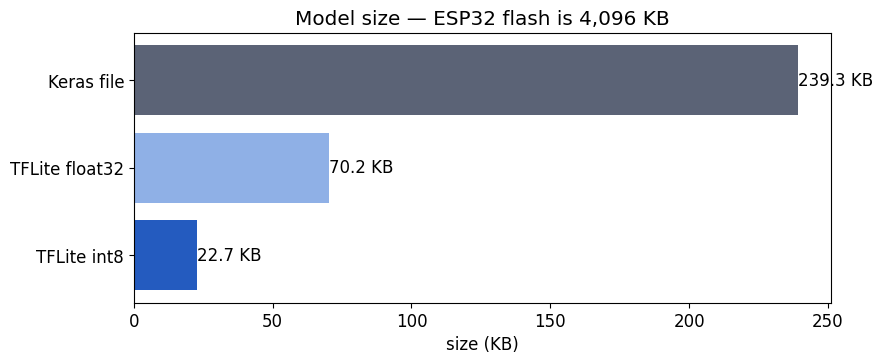

In [5]:
plt.figure(figsize=(9, 3.5))
bars = plt.barh(list(sizes.keys())[::-1], [v / 1024 for v in list(sizes.values())[::-1]], color=["#245BBF", "#8FB0E6", "#5B6376"])
plt.bar_label(bars, fmt="%.1f KB", fontsize=12)
plt.xlabel("size (KB)"); plt.title("Model size — ESP32 flash is 4,096 KB"); plt.show()

🧠 Where does the "4×" come from? 17,121 weights × 4 bytes ≈ 67 KB; × 1 byte ≈ 17 KB. The rest is the model's structure (layers, shapes).

---
## Part 3 · Is the tiny model still accurate?
We run both TFLite models with the **TFLite interpreter** — the same engine that runs on phones, the Raspberry Pi and (in C++) microcontrollers.

In [6]:
def run_tflite(model_bytes, X_data):
    interp = tf.lite.Interpreter(model_content=model_bytes)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]
    probs = []
    start = time.time()
    for beat in X_data:
        x = beat.reshape(1, 140, 1)
        if inp["dtype"] == np.int8:                          # int8 model: scale the input to int8
            scale, zero = inp["quantization"]
            x = np.round(x / scale + zero).clip(-128, 127).astype(np.int8)
        interp.set_tensor(inp["index"], x)
        interp.invoke()
        p = interp.get_tensor(out["index"])[0, 0]
        if out["dtype"] == np.int8:                          # and scale the output back
            scale, zero = out["quantization"]
            p = (float(p) - zero) * scale
        probs.append(p)
    ms = (time.time() - start) / len(X_data) * 1000
    return np.array(probs), ms

for name, m in [("TFLite float32", tflite_f32), ("TFLite int8", tflite_int8)]:
    probs, ms = run_tflite(m, X_test)
    acc = ((probs > 0.5).astype(int) == y_test).mean()
    print(f"{name:15s} accuracy {acc:.1%}   {ms:.3f} ms per heartbeat (on this computer)")
print(f"{'Keras (original)':15s} accuracy {keras_acc:.1%}")

TFLite float32  accuracy 99.3%   0.013 ms per heartbeat (on this computer)
TFLite int8     accuracy 99.3%   0.028 ms per heartbeat (on this computer)
Keras (original) accuracy 99.3%


In [7]:
# What does an int8 model look like inside?
interp = tf.lite.Interpreter(model_content=tflite_int8); interp.allocate_tensors()
print("Input :", interp.get_input_details()[0]["shape"], interp.get_input_details()[0]["dtype"].__name__,
      " scale/zero-point:", interp.get_input_details()[0]["quantization"])
print("Operations the chip must support:", sorted({op["op_name"] for op in interp._get_ops_details()} - {"DELEGATE"}))

Input : [  1 140   1] int8  scale/zero-point: (0.04397159814834595, 33)
Operations the chip must support: ['CONV_2D', 'FULLY_CONNECTED', 'LOGISTIC', 'MAX_POOL_2D', 'RESHAPE']


🧠 The **scale** and **zero-point** turn real numbers into int8: `int8 = round(value / scale) + zero_point`. That's all quantization is.

✍️ **Exercise 1:** make the model even smaller: change `Dense(32)` to `Dense(8)` in `build_model` and re-run Parts 1–3. How small does the int8 file get, and does accuracy drop?

---
## Part 4 · Export for the ESP32 (and Raspberry Pi)
A microcontroller has no file system, so the model becomes a **C array** — the bytes written out as numbers — compiled right into the program.

In [8]:
def to_c_array(data, name="ecg_model"):
    lines = [f"// Heartbeat classifier, int8, {len(data)} bytes", "#include <cstdint>", "",
             f"alignas(16) const unsigned char {name}[] = {{"]
    for i in range(0, len(data), 12):
        lines.append("  " + ", ".join(f"0x{b:02x}" for b in data[i:i+12]) + ",")
    lines += ["};", f"const unsigned int {name}_len = {len(data)};"]
    return "\n".join(lines)

header = to_c_array(tflite_int8)
open("ecg_model.h", "w").write(header)
print(header[:600], "\n...")
print("\necg_model.h written:", round(os.path.getsize("ecg_model.h") / 1024, 1), "KB of text")

// Heartbeat classifier, int8, 23288 bytes
#include <cstdint>

alignas(16) const unsigned char ecg_model[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  0x1c, 0x00, 0x00, 0x00, 0x8c, 0x00, 0x00, 0x00, 0xe4, 0x00, 0x00, 0x00,
  0x60, 0x46, 0x00, 0x00, 0x70, 0x46, 0x00, 0x00, 0x44, 0x5a, 0x00, 0x00,
  0x03, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00,
  0x3e, 0xb9, 0xff, 0xff, 0x0c, 0x00, 0x00, 0 
...

ecg_model.h written: 140.4 KB of text


In [9]:
# Quantization numbers the ESP32 sketch needs
inp = interp.get_input_details()[0]; out = interp.get_output_details()[0]
print(f"INPUT_SCALE = {inp['quantization'][0]:.8f};  INPUT_ZERO = {inp['quantization'][1]};")
print(f"OUTPUT_SCALE = {out['quantization'][0]:.8f};  OUTPUT_ZERO = {out['quantization'][1]};")

# One test heartbeat, to paste into the sketch for a first test
beat = X_test[0]
print("True label of X_test[0]:", "abnormal" if y_test[0] else "normal")
print("First 10 samples:", ", ".join(f"{v:.3f}" for v in beat[:10]), "...")
np.savetxt("test_beat.txt", beat[None], delimiter=", ", fmt="%.3f")    # all 140 values, ready to paste into the sketch

INPUT_SCALE = 0.04397160;  INPUT_ZERO = 33;
OUTPUT_SCALE = 0.00390625;  OUTPUT_ZERO = -128;
True label of X_test[0]: normal
First 10 samples: 0.613, -1.457, -2.913, -4.159, -4.294, -3.464, -2.273, -1.625, -1.531, -0.759 ...


### The Arduino sketch (ESP32)
This is a **template** for the Arduino IDE with the **TensorFlowLite_ESP32** library (Library Manager). Put `ecg_model.h` in the same folder as the sketch.

> ⚠️ Library versions change their header names; if a header is not found, check the library's own `hello_world` example — the rest of the code stays the same.

On a real device, the 140 samples come from an ECG front-end such as the **AD8232** board wired to an ESP32 analog pin, after R-peak detection (Notebook 1, Part 3).

In [ ]:
%%writefile ecg_esp32.ino
#include <TensorFlowLite_ESP32.h>
#include "tensorflow/lite/micro/micro_mutable_op_resolver.h"
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/schema/schema_generated.h"
#include "ecg_model.h"

// Paste the numbers printed in the notebook here
const float INPUT_SCALE = 0.0f, OUTPUT_SCALE = 0.0f;
const int   INPUT_ZERO = 0,     OUTPUT_ZERO = 0;

constexpr int kArenaSize = 20 * 1024;        // working memory for the model
alignas(16) uint8_t tensor_arena[kArenaSize];
tflite::MicroInterpreter* interpreter;

float beat[140];                              // one heartbeat: fill from the AD8232 sensor

void setup() {
  Serial.begin(115200);
  const tflite::Model* model = tflite::GetModel(ecg_model);
  static tflite::MicroMutableOpResolver<5> resolver;   // only the 5 operations our model uses
  resolver.AddConv2D(); resolver.AddMaxPool2D(); resolver.AddReshape();
  resolver.AddFullyConnected(); resolver.AddLogistic();
  static tflite::MicroInterpreter static_interpreter(model, resolver, tensor_arena, kArenaSize);
  interpreter = &static_interpreter;
  interpreter->AllocateTensors();
  Serial.println("Heartbeat model ready");
}

void loop() {
  // 1. read 140 samples around the next R peak into beat[] (not shown)
  TfLiteTensor* input = interpreter->input(0);
  for (int i = 0; i < 140; i++) {
    input->data.int8[i] = (int8_t) round(beat[i] / INPUT_SCALE + INPUT_ZERO);
  }
  interpreter->Invoke();
  int8_t raw = interpreter->output(0)->data.int8[0];
  float p_abnormal = (raw - OUTPUT_ZERO) * OUTPUT_SCALE;
  Serial.printf("P(abnormal) = %.2f %s\n", p_abnormal, p_abnormal > 0.5 ? "<-- CHECK" : "");
  delay(1000);
}

### On a Raspberry Pi
A Raspberry Pi runs normal Linux and Python, so it's much simpler — copy `ecg_int8.tflite` over and run:
```python
# on the Pi:  pip install ai-edge-litert
from ai_edge_litert.interpreter import Interpreter
interp = Interpreter(model_path="ecg_int8.tflite")
interp.allocate_tensors()
# ...then exactly the same set_tensor / invoke / get_tensor code as Part 3
```
The Pi can also run **YOLO from Day 4** with a camera: `pip install ultralytics`, then `YOLO("yolo11n.pt")(source=0)`.

In [ ]:
# Download the files to your computer (Colab only)
try:
    from google.colab import files
    for f in ["ecg_int8.tflite", "ecg_model.h", "ecg_esp32.ino"]:
        files.download(f)
except Exception:
    print("Not in Colab - the files are in the current folder:", [f for f in os.listdir(".") if f.startswith("ecg")])

---
## ✅ Summary
- TinyML = ML on microcontrollers: private, instant, no internet, runs for months on a battery.
- Workflow: **train (Colab) → convert (TFLite) → quantize (int8) → C array → flash the chip**.
- Our heart model: about 4× smaller after quantization with the same accuracy — easily fits the ESP32.
- Raspberry Pi = a small Linux computer: run the `.tflite` file (or YOLO) directly from Python.

---
## Solutions

In [ ]:
# Exercise 1: a smaller dense layer
def build_small(batch_size=None):
    return keras.Sequential([keras.Input(shape=(140, 1), batch_size=batch_size),
        layers.Conv1D(16, 7, activation="relu"), layers.MaxPooling1D(4),
        layers.Conv1D(32, 5, activation="relu"), layers.MaxPooling1D(2),
        layers.Flatten(), layers.Dense(8, activation="relu"), layers.Dense(1, activation="sigmoid")])
keras.utils.set_random_seed(42)
small = build_small(); small.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
small.fit(X_train[..., None], y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)
small1 = build_small(1); small1.set_weights(small.get_weights())
c = tf.lite.TFLiteConverter.from_keras_model(small1)
c.optimizations = [tf.lite.Optimize.DEFAULT]; c.representative_dataset = representative_data
c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
c.inference_input_type = tf.int8; c.inference_output_type = tf.int8
small_int8 = c.convert()
p, _ = run_tflite(small_int8, X_test)
print(f"Weights {small.count_params():,}  int8 size {len(small_int8)/1024:.1f} KB  accuracy {((p > 0.5) == y_test).mean():.1%}")